# Skateboard trick analysis — demo

Thin demo for the `skate_analysis` package. All logic lives in the modules; this notebook just calls the public API.

## Setup

The notebook lives inside the package, so its directory (`skate_analysis/`) is on `sys.path[0]` — but the package root is not. Insert the project root so `import skate_analysis` resolves.

In [1]:
import sys
from pathlib import Path

_project_root = Path.cwd().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))


In [2]:
import cv2
import matplotlib.pyplot as plt

from skate_analysis import (
    analyze_video,
    apply_norm_keypoints, normalize_board_keypoints,
    detect_direction, detect_tricks, detect_stance,
    compute_trick_rotations, compute_body_rotation,
    flip_label, classify_trick,
    render_frame, plot_metrics, plot_jump_height,
    _board_yaw_atan2_video,
)
from skate_analysis.classification import _board_spin_label, _body_spin_label


---
# Classification helpers

In [3]:
print("=== flip_label ===")
for is_reg in (True, False):
    for flip in (+1, -1):
        for st in ("normal", "switch", "nollie", "fakie"):
            print(f"  is_regular={is_reg!s:5}  flip={flip:+d}  stance={st:7}  -> {flip_label(flip, st, is_reg)}")

print("=== _board_spin_label (snap to 0/180/360/540/720, tol=45) ===")
for v in [0, 12, -38, 50, 90, 135, 178, -183, 225, 270, 315, 360, 405, 450, 540, 630, 720]:
    print(f"  yaw={v:+5}  -> {_board_spin_label(v)}")

print("=== _body_spin_label ===")
for v in [0, 180, -180, 360, 540, 720]:
    print(f"  body={v:+5}  -> {_body_spin_label(v)}")


=== flip_label ===
  is_regular=True   flip=+1  stance=normal   -> heelflip
  is_regular=True   flip=+1  stance=switch   -> kickflip
  is_regular=True   flip=+1  stance=nollie   -> heelflip
  is_regular=True   flip=+1  stance=fakie    -> kickflip
  is_regular=True   flip=-1  stance=normal   -> kickflip
  is_regular=True   flip=-1  stance=switch   -> heelflip
  is_regular=True   flip=-1  stance=nollie   -> kickflip
  is_regular=True   flip=-1  stance=fakie    -> heelflip
  is_regular=False  flip=+1  stance=normal   -> kickflip
  is_regular=False  flip=+1  stance=switch   -> heelflip
  is_regular=False  flip=+1  stance=nollie   -> kickflip
  is_regular=False  flip=+1  stance=fakie    -> heelflip
  is_regular=False  flip=-1  stance=normal   -> heelflip
  is_regular=False  flip=-1  stance=switch   -> kickflip
  is_regular=False  flip=-1  stance=nollie   -> heelflip
  is_regular=False  flip=-1  stance=fakie    -> kickflip
=== _board_spin_label (snap to 0/180/360/540/720, tol=45) ===
  yaw= 

---
# Full pipeline

direction=rtl  stance=normal  is_regular=False  tricks=1



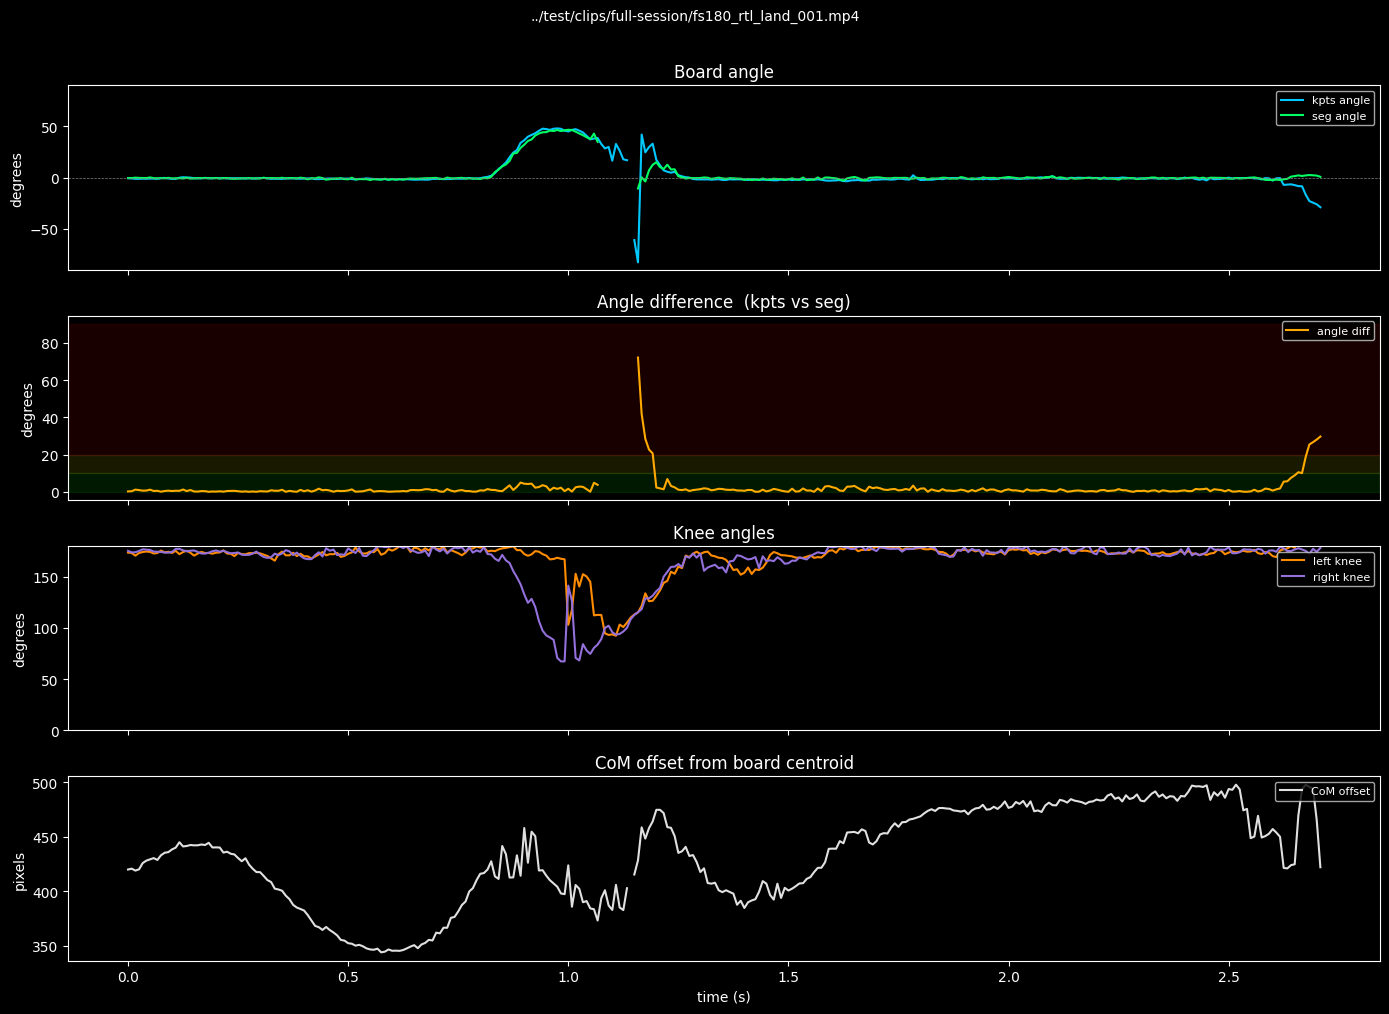

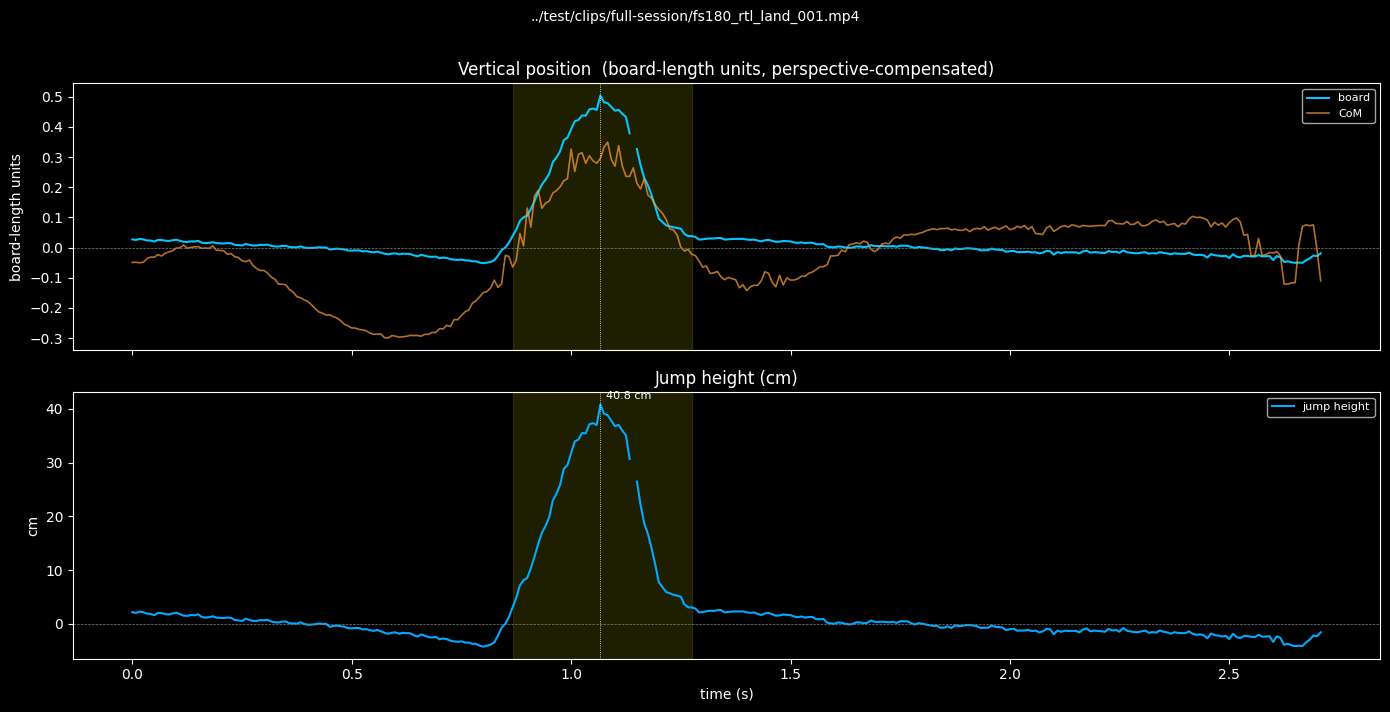

trick 1: 0.87s -> 1.27s  (peak nancm @ 1.14s)
  raw:   yaw=+170.6deg  flip=+0  body=+180deg
  name:  'FS 180'


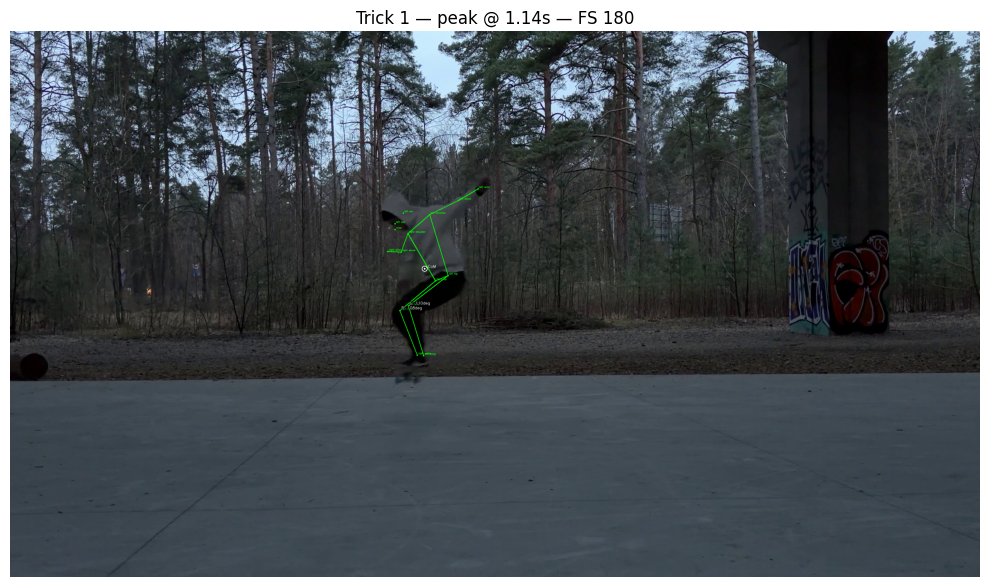

In [4]:
def demo_full_pipeline(video_path):
    is_regular = False  # goofy

    # 1) Per-frame analysis: human pose + skate segmentation + skate keypoints
    analyses, frame_numbers, fps = analyze_video(video_path)
    apply_norm_keypoints(analyses, normalize_board_keypoints(analyses, frame_numbers, fps))

    # 2) Detection: travel direction, trick intervals, stance
    direction = detect_direction(analyses, frame_numbers, fps)
    tricks    = detect_tricks(analyses, frame_numbers, fps)
    stance    = detect_stance(analyses, frame_numbers, fps,
                              is_regular=is_regular, tricks=tricks, direction=direction)

    print(f"direction={direction}  stance={stance}  is_regular={is_regular}  tricks={len(tricks)}")
    print()

    # 3) Time-series metrics: board angle (kpts vs seg), angle diff, knee angles, CoM offset
    plot_metrics(analyses, frame_numbers, fps, title=video_path)

    # 4) Jump height + detected trick intervals + peaks
    plot_jump_height(analyses, frame_numbers, fps, title=video_path)

    # 5) Per-trick rotation, classification, peak-frame overlay
    yaw_series, _, _ = _board_yaw_atan2_video(analyses)
    cap = cv2.VideoCapture(video_path)

    for i, t in enumerate(tricks, 1):
        rot  = compute_trick_rotations(analyses, t, frame_numbers, fps, yaw_series=yaw_series)
        y_sign = 1 if (rot["yaw_deg"] is None or rot["yaw_deg"] >= 0) else -1
        brot = compute_body_rotation(analyses, t, frame_numbers, fps, yaw_sign=y_sign)
        body_raw = (brot.get("shoulder_rot_deg") or brot.get("hip_rot_deg")
                    or brot.get("wrist_rot_deg")   or brot.get("ankle_rot_deg"))

        name = classify_trick(rot["yaw_deg"], rot["flip_count"], body_raw,
                              stance, is_regular)

        yaw_s  = f"{rot['yaw_deg']:+.1f}" if rot["yaw_deg"]    is not None else "n/a"
        flip_s = f"{rot['flip_count']:+d}" if rot["flip_count"] is not None else "n/a"
        body_s = f"{body_raw:+d}" if body_raw is not None else "n/a"

        print(f"trick {i}: {t.start_time:.2f}s -> {t.end_time:.2f}s  (peak {t.peak_height_cm:.1f}cm @ {t.peak_time:.2f}s)")
        print(f"  raw:   yaw={yaw_s}deg  flip={flip_s}  body={body_s}deg")
        print(f"  name:  {name!r}")

        # Render peak frame with all overlays (pose, segmentation, kpts, PCA, metrics)
        cap.set(cv2.CAP_PROP_POS_FRAMES, t.peak_frame)
        ok, frame = cap.read()
        if not ok:
            continue
        idx = min(range(len(frame_numbers)),
                  key=lambda k: abs(frame_numbers[k] - t.peak_frame))
        vis = render_frame(frame, analyses[idx])
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(vis)
        ax.set_title(f"Trick {i} — peak @ {t.peak_time:.2f}s — {name}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    cap.release()


demo_full_pipeline("../test/clips/full-session/fs180_rtl_land_001.mp4")
